# EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load cleaned data

In [2]:
df = pd.read_csv("retail_forecasting_cleaned_v2.csv")
df["date"] = pd.to_datetime(df["date"])
df["launch_date"] = pd.to_datetime(df["launch_date"])
print("Rows",len(df))
print("Columns",len(df.columns))
print("\n Columns")
print(df.columns.tolist())

print("\n Dataset shape",df.shape)

Rows 365000
Columns 22

 Columns
['date', 'sku_id', 'category', 'subcategory', 'launch_date', 'unit_cost', 'list_price', 'units_sold', 'revenue', 'unit_price', 'promo_flag', 'on_hand_units', 'on_order_units', 'lead_time_days', 'reorder_point', 'week', 'month', 'season', 'is_holiday', 'promo_event', 'region', 'is_stockout']

 Dataset shape (365000, 22)


# # 1. FIX calendar columns (week / month / season)

In [3]:
df["month"] = df["date"].dt.month
df["week"]  = df["date"].dt.isocalendar().week.astype(int)

def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Fall"

df["season"] = df["month"].apply(get_season)

print("Calendar fixed.")
print(df[["date", "week", "month", "season"]].head(10))

Calendar fixed.
        date  week  month  season
0 2021-08-14    32      8  Summer
1 2021-08-15    32      8  Summer
2 2021-08-16    33      8  Summer
3 2021-08-17    33      8  Summer
4 2021-08-18    33      8  Summer
5 2021-08-19    33      8  Summer
6 2021-08-20    33      8  Summer
7 2021-08-21    33      8  Summer
8 2021-08-22    33      8  Summer
9 2021-08-23    34      8  Summer


# # 2. DEAD STOCK / SLOW MOVERS

In [4]:
# Define "recent" window (last 90 days of data)
latest_date = df["date"].max()
cutoff = latest_date - pd.Timedelta(days=90)

recent = df[df["date"] >= cutoff]

sku_recent = recent.groupby("sku_id").agg(
    recent_units=("units_sold", "sum"),
    recent_revenue=("revenue", "sum"),
    avg_on_hand=("on_hand_units", "mean"),
    last_on_hand=("on_hand_units", "last")
).reset_index()

# Full history for context
sku_full = df.groupby("sku_id").agg(
    total_units=("units_sold", "sum"),
    total_revenue=("revenue", "sum"),
    category=("category", "first"),
    subcategory=("subcategory", "first")
).reset_index()

dead_stock = sku_recent.merge(sku_full, on="sku_id")

# Flag rules (adjust thresholds if needed)
dead_stock["is_dead"] = (
    (dead_stock["recent_units"] == 0) &
    (dead_stock["last_on_hand"] > 0)
    )

dead_stock["is_slow"] = (
    (dead_stock["recent_units"] > 0) &
    (dead_stock["recent_units"] <= 5) &          # very low recent demand
    (dead_stock["last_on_hand"] > dead_stock["recent_units"] * 4)
)

print("\n===== DEAD STOCK =====")
print("Dead SKUs (0 sales in last 90 days but still have stock):",
      dead_stock["is_dead"].sum())
print(dead_stock[dead_stock["is_dead"]][
    ["sku_id", "category", "recent_units", "last_on_hand", "total_revenue"]
].sort_values("last_on_hand", ascending=False).head(15))

print("\n===== SLOW MOVERS =====")
print("Slow SKUs:", dead_stock["is_slow"].sum())
print(dead_stock[dead_stock["is_slow"]][
    ["sku_id", "category", "recent_units", "last_on_hand", "total_revenue"]
].sort_values("last_on_hand", ascending=False).head(15))

# Capital locked in dead + slow stock (approx)
locked = dead_stock[dead_stock["is_dead"] | dead_stock["is_slow"]].copy()
# approximate value using average unit cost from original data if available
# (here we just show units)
print("\nTotal on-hand units in dead/slow SKUs:",
      locked["last_on_hand"].sum())


===== DEAD STOCK =====
Dead SKUs (0 sales in last 90 days but still have stock): 0
Empty DataFrame
Columns: [sku_id, category, recent_units, last_on_hand, total_revenue]
Index: []

===== SLOW MOVERS =====
Slow SKUs: 0
Empty DataFrame
Columns: [sku_id, category, recent_units, last_on_hand, total_revenue]
Index: []

Total on-hand units in dead/slow SKUs: 0


# # 3. STOCKOUT HISTORY

In [5]:
# True stockout day: on_hand == 0
df["is_stockout"] = df["on_hand_units"] == 0

# Lost sales proxy: stockout day AND we would have expected demand
# (simple version: stockout + previous day had sales)
df = df.sort_values(["sku_id", "date"])
df["prev_units"] = df.groupby("sku_id")["units_sold"].shift(1)
df["potential_lost_sale"] = (
    (df["is_stockout"]) &
    (df["prev_units"] > 0)
)

stockout_summary = df.groupby("sku_id").agg(
    stockout_days=("is_stockout", "sum"),
    potential_lost_days=("potential_lost_sale", "sum"),
    total_units=("units_sold", "sum"),
    total_revenue=("revenue", "sum"),
    category=("category", "first")
).reset_index()

stockout_summary = stockout_summary.sort_values(
    "stockout_days", ascending=False
)

print("\n===== STOCKOUT SUMMARY =====")
print("SKUs that ever hit zero inventory:",
      (stockout_summary["stockout_days"] > 0).sum())
print("\nTop 15 SKUs by stockout days:")
print(stockout_summary.head(15)[
    ["sku_id", "category", "stockout_days",
     "potential_lost_days", "total_revenue"]
])

# Overall rates
print("\n% of all records that are stockout days:",
      round(df["is_stockout"].mean() * 100, 2), "%")
print("% of records with potential lost sales:",
      round(df["potential_lost_sale"].mean() * 100, 2), "%")


===== STOCKOUT SUMMARY =====
SKUs that ever hit zero inventory: 198

Top 15 SKUs by stockout days:
      sku_id          category  stockout_days  potential_lost_days  \
126  SKU0127  Small Appliances            577                  117   
191  SKU0192  Small Appliances            473                   95   
48   SKU0049  Small Appliances            463                  126   
55   SKU0056         Furniture            431                  122   
21   SKU0022             Decor            420                  133   
127  SKU0128         Furniture            401                  132   
65   SKU0066             Decor            384                  169   
165  SKU0166         Furniture            379                  131   
125  SKU0126         Furniture            371                  132   
194  SKU0195         Furniture            360                  114   
147  SKU0148             Decor            360                  137   
42   SKU0043             Decor            357               

# 4. Quick visual checks (optional)

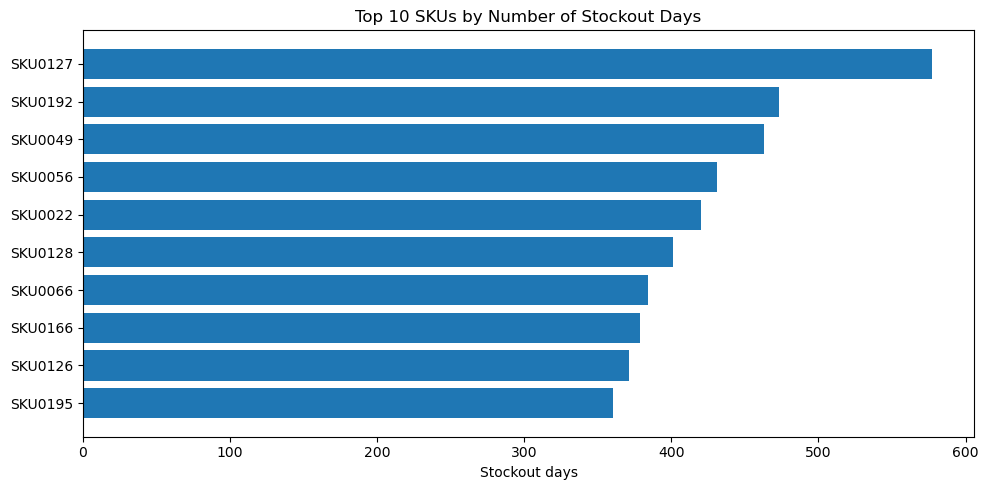

In [6]:
# Dead stock bar
top_dead = dead_stock[dead_stock["is_dead"]].nlargest(10, "last_on_hand")
if len(top_dead) > 0:
    plt.figure(figsize=(10, 5))
    plt.barh(top_dead["sku_id"], top_dead["last_on_hand"])
    plt.title("Top Dead Stock SKUs by On-Hand Units (last 90 days = 0 sales)")
    plt.xlabel("On-hand units")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

# Stockout days
top_so = stockout_summary.head(10)
plt.figure(figsize=(10, 5))
plt.barh(top_so["sku_id"], top_so["stockout_days"])
plt.title("Top 10 SKUs by Number of Stockout Days")
plt.xlabel("Stockout days")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# retail_forecasting_cleaned

In [7]:
print("===== OVERALL SALES & REVENUE =====")

print("Total units sold:", df["units_sold"].sum())
print("Total revenue:", df["revenue"].sum())

print("Average units sold per record:", df["units_sold"].mean())
print("Average revenue per record:", df["revenue"].mean())

print("\nUnits sold statistics:")
print(df["units_sold"].describe())

print("\nRevenue statistics:")
print(df["revenue"].describe())

===== OVERALL SALES & REVENUE =====
Total units sold: 2009214
Total revenue: 616656027.7
Average units sold per record: 5.504695890410959
Average revenue per record: 1689.468569041096

Units sold statistics:
count    365000.000000
mean          5.504696
std           6.170807
min           0.000000
25%           1.000000
50%           4.000000
75%           8.000000
max         108.000000
Name: units_sold, dtype: float64

Revenue statistics:
count    365000.000000
mean       1689.468569
std        3101.952615
min           0.000000
25%         121.800000
50%         614.790000
75%        1870.815000
max       80408.210000
Name: revenue, dtype: float64


# Sales over time

In [8]:
print("===== SALES OVER TIME =====")

daily_sales = df.groupby("date").agg(
    units_sold=("units_sold", "sum"),
    revenue=("revenue", "sum")
).reset_index()

print(daily_sales.head())
print("\nDaily sales summary:")
print(daily_sales[["units_sold", "revenue"]].describe())

===== SALES OVER TIME =====
        date  units_sold    revenue
0 2021-08-14         795  245209.48
1 2021-08-15         751  222046.59
2 2021-08-16         669  204243.15
3 2021-08-17         705  204718.33
4 2021-08-18         715  213259.98

Daily sales summary:
        units_sold        revenue
count  1825.000000    1825.000000
mean   1100.939178  337893.713808
std     452.748617  109938.505597
min     464.000000  134768.160000
25%     828.000000  264875.800000
50%     973.000000  315566.640000
75%    1148.000000  378896.780000
max    3460.000000  991569.140000


# EDA plot: daily revenue over time. 

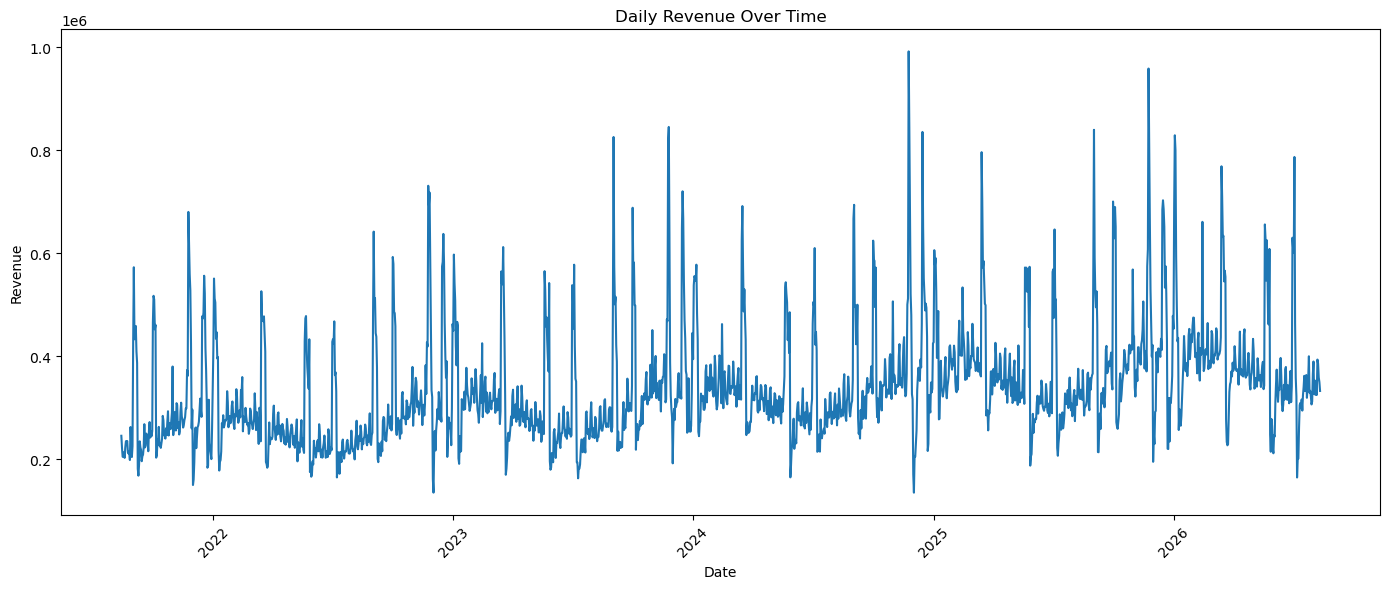

In [9]:
plt.figure(figsize=(14, 6))

plt.plot(
    daily_sales["date"],
    daily_sales["revenue"]
)

plt.title("Daily Revenue Over Time")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Monthly sales pattern

In [10]:
df["date"] = pd.to_datetime(df["date"])

print(df["date"].dtype)

datetime64[ns]


In [11]:
monthly_sales = df.groupby(
    df["date"].dt.to_period("M")
).agg(
    units_sold=("units_sold", "sum"),
    revenue=("revenue", "sum")
).reset_index()

monthly_sales["date"] = monthly_sales["date"].dt.to_timestamp()

print(monthly_sales.head())
print("\nNumber of months:", len(monthly_sales))

        date  units_sold     revenue
0 2021-08-01       13073  3971893.91
1 2021-09-01       28335  8364079.93
2 2021-10-01       28959  9040157.54
3 2021-11-01       32425  9917890.12
4 2021-12-01       29994  9211733.10

Number of months: 61


# Monthly Revenue Plot

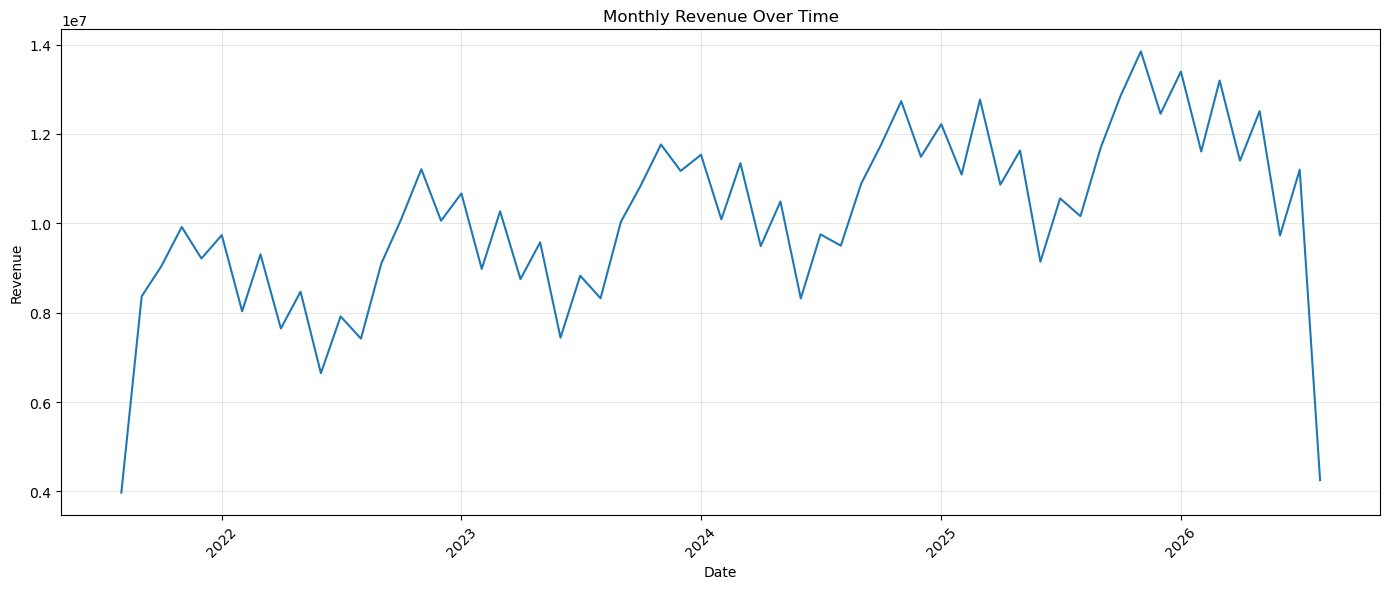

In [12]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales["date"],
    monthly_sales["revenue"]
)

plt.title("Monthly Revenue Over Time")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Monthly seasonality

In [13]:
print("===== MONTHLY SEASONALITY =====")

seasonality = (
    monthly_sales[
        (monthly_sales["date"] > "2021-08-01") &
        (monthly_sales["date"] < "2026-08-01")
    ]
    .assign(month=monthly_sales["date"].dt.month)
    .groupby("month")
    .agg(
        average_revenue=("revenue", "mean"),
        average_units_sold=("units_sold", "mean")
    )
    .reset_index()
)

print(seasonality)

===== MONTHLY SEASONALITY =====
    month  average_revenue  average_units_sold
0       1     1.150939e+07             36442.6
1       2     9.958752e+06             29525.8
2       3     1.137531e+07             37282.4
3       4     9.629864e+06             30426.0
4       5     1.053364e+07             37317.8
5       6     8.254159e+06             27830.4
6       7     9.649311e+06             34766.2
7       8     8.849650e+06             28705.0
8       9     1.001587e+07             33297.6
9      10     1.091090e+07             34191.8
10     11     1.189383e+07             37829.8
11     12     1.087567e+07             34633.0


# Plot the seasonality

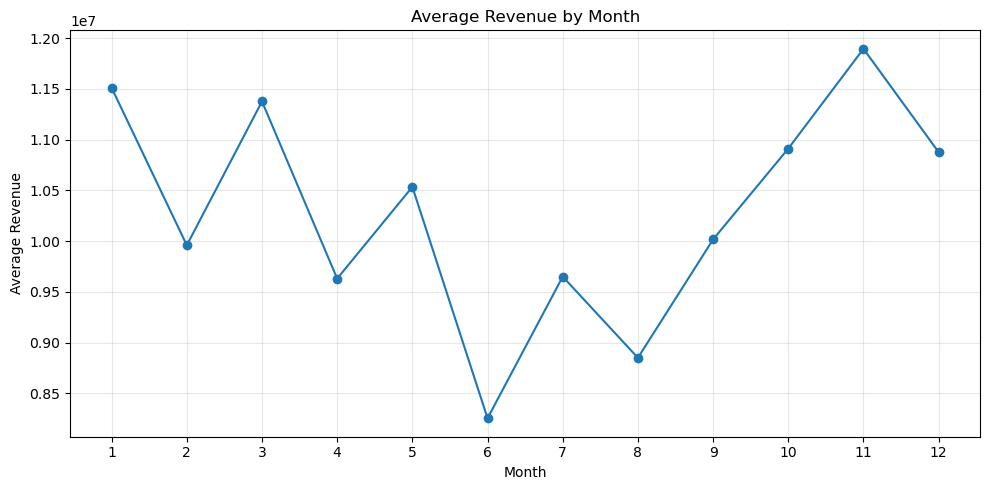

In [14]:
plt.figure(figsize=(10, 5))

plt.plot(
    seasonality["month"],
    seasonality["average_revenue"],
    marker="o"
)

plt.title("Average Revenue by Month")
plt.xlabel("Month")
plt.ylabel("Average Revenue")
plt.xticks(range(1, 13))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Category-level sales analysis.

In [15]:
category_sales = df.groupby("category").agg(
    units_sold=("units_sold", "sum"),
    revenue=("revenue", "sum")
).reset_index()

category_sales = category_sales.sort_values(
    "revenue", ascending=False
)

print("===== SALES BY CATEGORY =====")
print(category_sales)

===== SALES BY CATEGORY =====
           category  units_sold       revenue
1         Furniture      880026  4.814539e+08
2  Small Appliances      397272  6.970879e+07
0             Decor      731916  6.549334e+07


# Category revenue plot

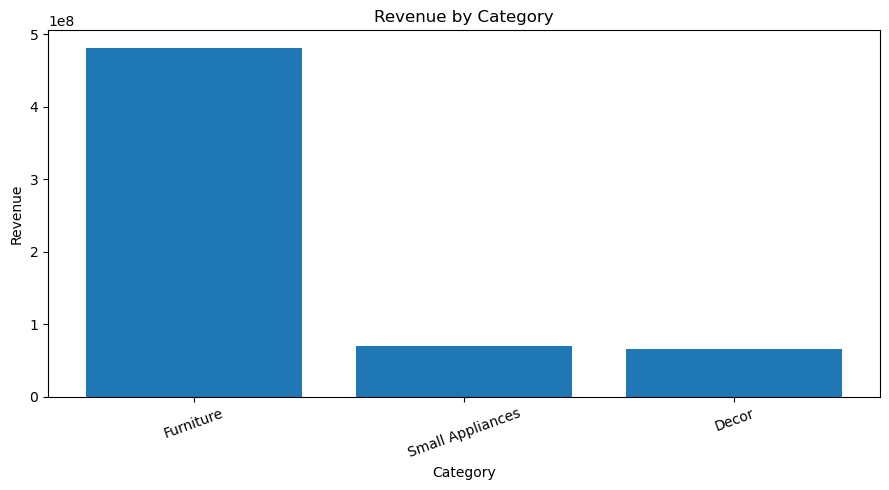

In [16]:
plt.figure(figsize=(9, 5))

plt.bar(
    category_sales["category"],
    category_sales["revenue"]
)

plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# Subcategory analysis

In [17]:
subcategory_sales = df.groupby("subcategory").agg(
    units_sold=("units_sold", "sum"),
    revenue=("revenue", "sum")
).reset_index()

subcategory_sales = subcategory_sales.sort_values(
    "revenue", ascending=False
)

print("===== SALES BY SUBCATEGORY =====")
print(subcategory_sales)

===== SALES BY SUBCATEGORY =====
                 subcategory  units_sold       revenue
7                      Sofas      198928  1.231076e+08
4          Outdoor Furniture      176740  1.138246e+08
8                    Storage      185059  9.314967e+07
1                     Chairs      179573  9.121867e+07
9                     Tables      139726  6.015328e+07
0                   Air Care      162059  3.090747e+07
5   Personal Care Appliances      135289  2.160288e+07
12                  Wall Art      199398  1.842392e+07
2         Kitchen Appliances       99924  1.719844e+07
10                  Textiles      180865  1.613883e+07
11          Vases & Planters      153740  1.322054e+07
3                   Lighting      120735  1.042296e+07
6                       Rugs       77178  7.287095e+06


 # Subcategory revenue plot

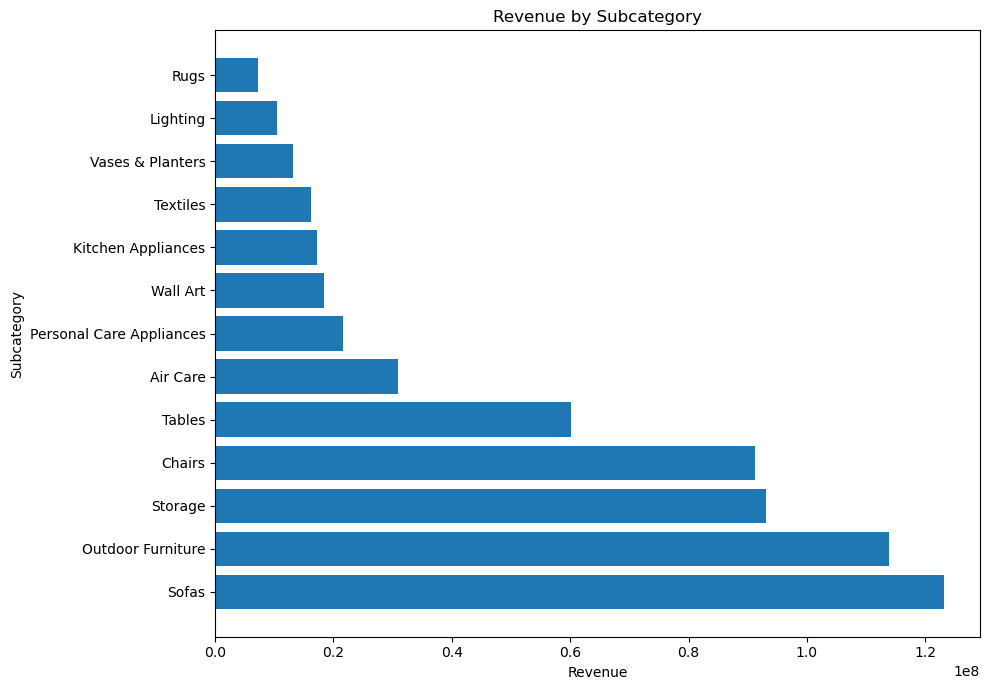

In [18]:
plt.figure(figsize=(10, 7))

plt.barh(
    subcategory_sales["subcategory"],
    subcategory_sales["revenue"]
)

plt.title("Revenue by Subcategory")
plt.xlabel("Revenue")
plt.ylabel("Subcategory")

plt.tight_layout()
plt.show()

# Regional analysis

In [19]:
region_sales = df.groupby("region").agg(
    units_sold=("units_sold", "sum"),
    revenue=("revenue", "sum")
).reset_index()

region_sales = region_sales.sort_values(
    "revenue", ascending=False
)

print("===== SALES BY REGION =====")
print(region_sales)

===== SALES BY REGION =====
  region  units_sold       revenue
0   East      503479  1.546048e+08
1  North      501990  1.544424e+08
3   West      502743  1.538904e+08
2  South      501002  1.537184e+08


# plot revenue by region

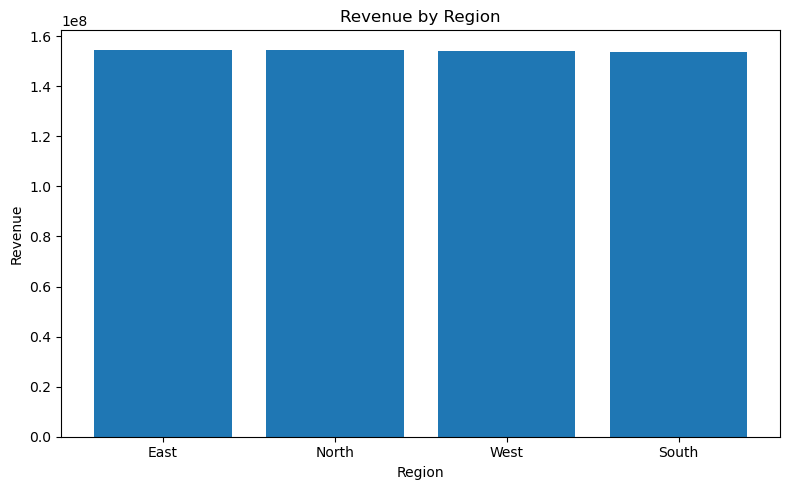

In [20]:
plt.figure(figsize=(8, 5))

plt.bar(
    region_sales["region"],
    region_sales["revenue"]
)

plt.title("Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

# Promotion analysis
Now we want to determine whether promotions are associated with higher sales and revenue.

In [21]:
promo_sales = df.groupby("promo_flag").agg(
    units_sold=("units_sold", "sum"),
    revenue=("revenue", "sum"),
    avg_units_sold=("units_sold", "mean"),
    avg_revenue=("revenue", "mean")
).reset_index()

print("===== PROMOTION ANALYSIS =====")
print(promo_sales)

===== PROMOTION ANALYSIS =====
   promo_flag  units_sold      revenue  avg_units_sold  avg_revenue
0       False     1445543  470348414.8        4.678133  1522.163155
1        True      563671  146307612.9       10.065554  2612.635945


# Promotion Visualization

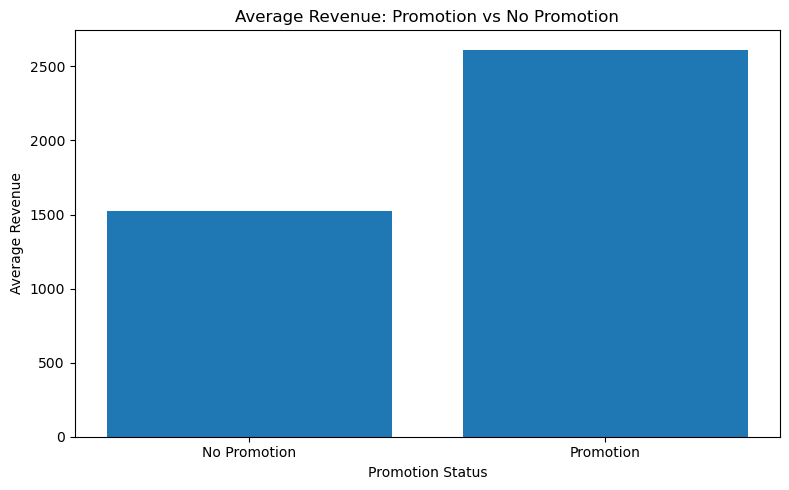

In [22]:
plt.figure(figsize=(8, 5))

plt.bar(
    ["No Promotion", "Promotion"],
    promo_sales["avg_revenue"]
)

plt.title("Average Revenue: Promotion vs No Promotion")
plt.xlabel("Promotion Status")
plt.ylabel("Average Revenue")

plt.tight_layout()
plt.show()

# Holiday analysis

Now check whether holidays are associated with different sales performance.

In [23]:
holiday_sales = df.groupby("is_holiday").agg(
    units_sold=("units_sold", "sum"),
    revenue=("revenue", "sum"),
    avg_units_sold=("units_sold", "mean"),
    avg_revenue=("revenue", "mean")
).reset_index()

print("===== HOLIDAY ANALYSIS =====")
print(holiday_sales)

===== HOLIDAY ANALYSIS =====
   is_holiday  units_sold       revenue  avg_units_sold  avg_revenue
0       False     1926093  5.913515e+08        5.502918  1689.512968
1        True       83121  2.530453e+07        5.546207  1688.431661


# Holiday visualization

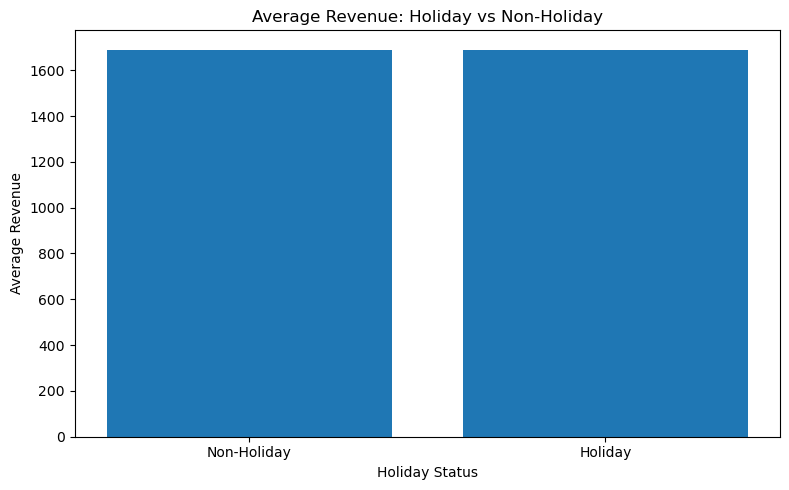

In [24]:
plt.figure(figsize=(8, 5))

plt.bar(
    ["Non-Holiday", "Holiday"],
    holiday_sales["avg_revenue"]
)

plt.title("Average Revenue: Holiday vs Non-Holiday")
plt.xlabel("Holiday Status")
plt.ylabel("Average Revenue")

plt.tight_layout()
plt.show()

In [25]:
price_analysis = df[[
    "unit_price",
    "units_sold",
    "revenue"
]].describe()

print("===== PRICE & SALES STATISTICS =====")
print(price_analysis)

===== PRICE & SALES STATISTICS =====
          unit_price     units_sold        revenue
count  365000.000000  365000.000000  365000.000000
mean      304.925847       5.504696    1689.468569
std       268.469216       6.170807    3101.952615
min        16.740000       0.000000       0.000000
25%       101.920000       1.000000     121.800000
50%       184.740000       4.000000     614.790000
75%       477.260000       8.000000    1870.815000
max      1052.430000     108.000000   80408.210000


# we should check is whether price and units sold are correlated. 

In [26]:
price_correlation = df[[
    "unit_price",
    "units_sold",
    "revenue"
]].corr()

print("===== PRICE & SALES CORRELATION =====")
print(price_correlation)

===== PRICE & SALES CORRELATION =====
            unit_price  units_sold   revenue
unit_price    1.000000    0.006606  0.490620
units_sold    0.006606    1.000000  0.673605
revenue       0.490620    0.673605  1.000000


# Price vs Units Sold plot

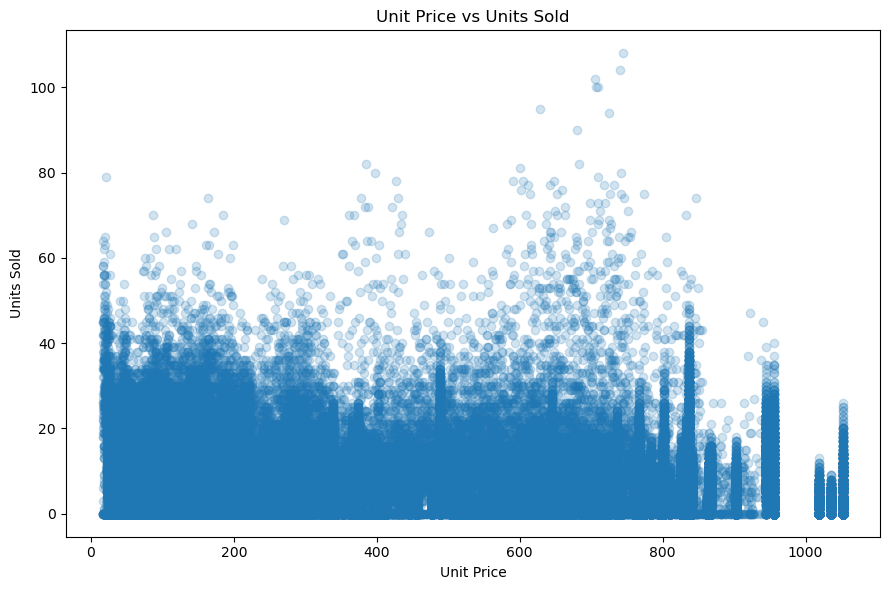

In [27]:
plt.figure(figsize=(9, 6))

plt.scatter(
    df["unit_price"],
    df["units_sold"],
    alpha=0.2
)

plt.title("Unit Price vs Units Sold")
plt.xlabel("Unit Price")
plt.ylabel("Units Sold")

plt.tight_layout()
plt.show()

# Inventory analysis

Since this is a retail forecasting dataset, inventory behavior is important. Next we'll examine on_hand_units, reorder_point, and on_order_units.

In [28]:
inventory_analysis = df[[
    "on_hand_units",
    "on_order_units",
    "reorder_point"
]].describe()

print("===== INVENTORY STATISTICS =====")
print(inventory_analysis)

===== INVENTORY STATISTICS =====
       on_hand_units  on_order_units  reorder_point
count  365000.000000   364857.000000  365000.000000
mean       74.135279       67.590267      93.010000
std        72.035313       83.426919      59.878374
min         0.000000        0.000000       9.000000
25%        22.000000        0.000000      50.750000
50%        56.000000       41.000000      81.000000
75%       104.000000      110.000000     121.500000
max       658.000000      516.000000     306.000000


# Stockout / low-inventory analysis 
Let's check how often inventory falls below the reorder point.

In [29]:
df["below_reorder_point"] = (
    df["on_hand_units"] < df["reorder_point"]
)

print("===== INVENTORY RISK ANALYSIS =====")

print(
    "Records below reorder point:",
    df["below_reorder_point"].sum()
)

print(
    "Percentage below reorder point:",
    df["below_reorder_point"].mean() * 100
)

===== INVENTORY RISK ANALYSIS =====
Records below reorder point: 221816
Percentage below reorder point: 60.771506849315074


# visualize inventory risk

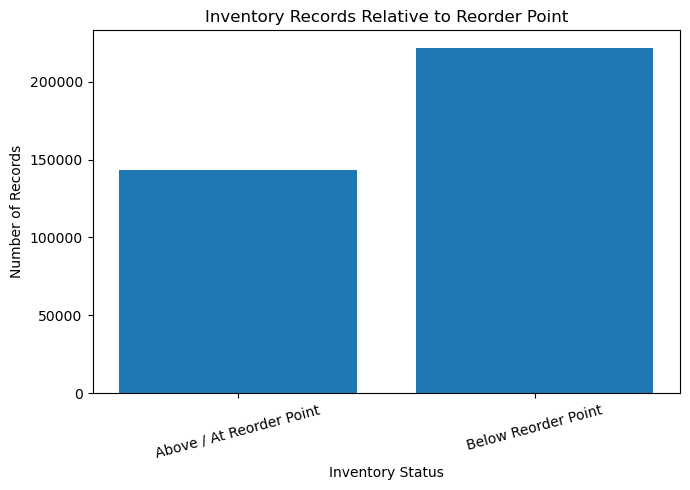

In [30]:
risk_counts = df["below_reorder_point"].value_counts()

plt.figure(figsize=(7, 5))

plt.bar(
    ["Above / At Reorder Point", "Below Reorder Point"],
    [
        risk_counts.get(False, 0),
        risk_counts.get(True, 0)
    ]
)

plt.title("Inventory Records Relative to Reorder Point")
plt.xlabel("Inventory Status")
plt.ylabel("Number of Records")
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

# LEAD TIME ANALYSIS

In [31]:
print("===== LEAD TIME ANALYSIS =====")

print(df["lead_time_days"].describe())

print("\nLead time frequency:")
print(df["lead_time_days"].value_counts().sort_index())

===== LEAD TIME ANALYSIS =====
count    365000.00000
mean         13.27500
std           4.37372
min           7.00000
25%          10.00000
50%          13.00000
75%          16.00000
max          27.00000
Name: lead_time_days, dtype: float64

Lead time frequency:
lead_time_days
7     32850
8     25550
9     27375
10    25550
11    23725
12    31025
13    23725
14    31025
15    32850
16    41975
17    29200
18     9125
19     1825
20     5475
21     1825
22     3650
23     7300
24     3650
25     3650
27     3650
Name: count, dtype: int64


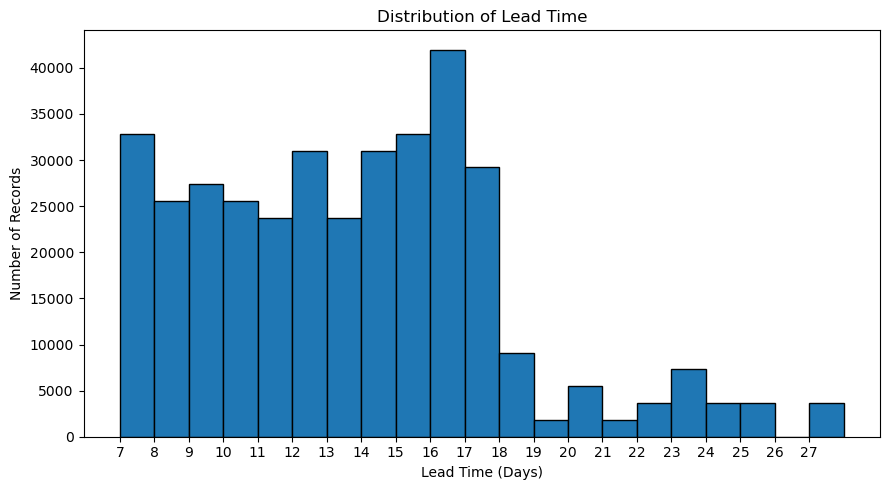

In [32]:
# visualize the distribution.
plt.figure(figsize=(9, 5))

plt.hist(
    df["lead_time_days"],
    bins=range(7, 29),
    edgecolor="black"
)

plt.title("Distribution of Lead Time")
plt.xlabel("Lead Time (Days)")
plt.ylabel("Number of Records")

plt.xticks(range(7, 28))
plt.tight_layout()
plt.show()

 # Promo event analysis

In [33]:
print("===== PROMO EVENT ANALYSIS =====")

promo_event_analysis = df.groupby("promo_event").agg(
    units_sold=("units_sold", "sum"),
    revenue=("revenue", "sum"),
    avg_units_sold=("units_sold", "mean"),
    avg_revenue=("revenue", "mean")
).reset_index()

promo_event_analysis = promo_event_analysis.sort_values(
    "revenue", ascending=False
)

print(promo_event_analysis)

===== PROMO EVENT ANALYSIS =====
                   promo_event  units_sold       revenue  avg_units_sold  \
6        No Promotion Recorded     1224469  3.985713e+08        4.680048   
9            Unknown Promotion      476368  1.235526e+08       10.048898   
4            Memorial Day Sale       43101  1.349822e+07        5.387625   
2       Holiday Countdown Sale       44316  1.340688e+07        5.545045   
7          Spring Refresh Sale       38910  1.204840e+07        5.564136   
3               Labor Day Sale       38598  1.195733e+07        5.519520   
1  Black Friday / Cyber Monday       39062  1.181160e+07        5.585872   
5           New Year Clearance       38677  1.173474e+07        5.530817   
8             Summer Home Sale       38313  1.173025e+07        5.473286   
0             Anniversary Sale       27400  8.344629e+06        5.485485   

   avg_revenue  
6  1523.381112  
9  2606.320895  
4  1687.277341  
2  1677.537694  
7  1722.922913  
3  1709.899512  
1  1689.060

# visualize promo-event revenue

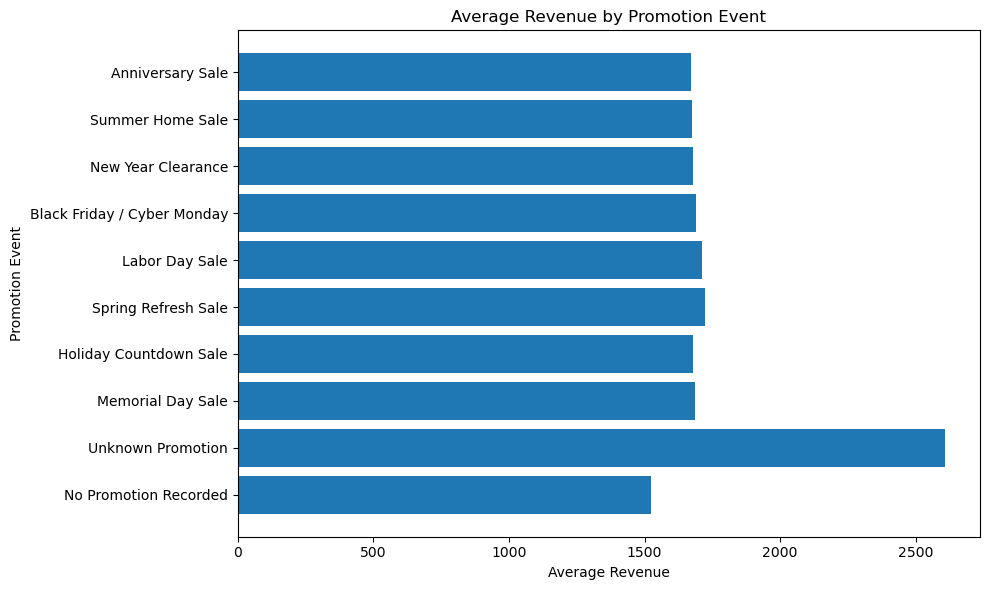

In [34]:
plt.figure(figsize=(10, 6))

plt.barh(
    promo_event_analysis["promo_event"],
    promo_event_analysis["avg_revenue"]
)

plt.title("Average Revenue by Promotion Event")
plt.xlabel("Average Revenue")
plt.ylabel("Promotion Event")

plt.tight_layout()
plt.show()

# Seasonality by season

In [35]:
print("===== SALES BY SEASON =====")

season_sales = df.groupby("season").agg(
    units_sold=("units_sold", "sum"),
    revenue=("revenue", "sum"),
    avg_units_sold=("units_sold", "mean"),
    avg_revenue=("revenue", "mean")
).reset_index()

season_sales = season_sales.sort_values(
    "revenue", ascending=False
)

print(season_sales)

===== SALES BY SEASON =====
   season  units_sold       revenue  avg_units_sold  avg_revenue
0    Fall      526596  1.641030e+08        5.786769  1803.330033
3  Winter      503007  1.617190e+08        5.576574  1792.893946
1  Spring      525131  1.576941e+08        5.707946  1714.066071
2  Summer      454480  1.331399e+08        4.950763  1450.325514


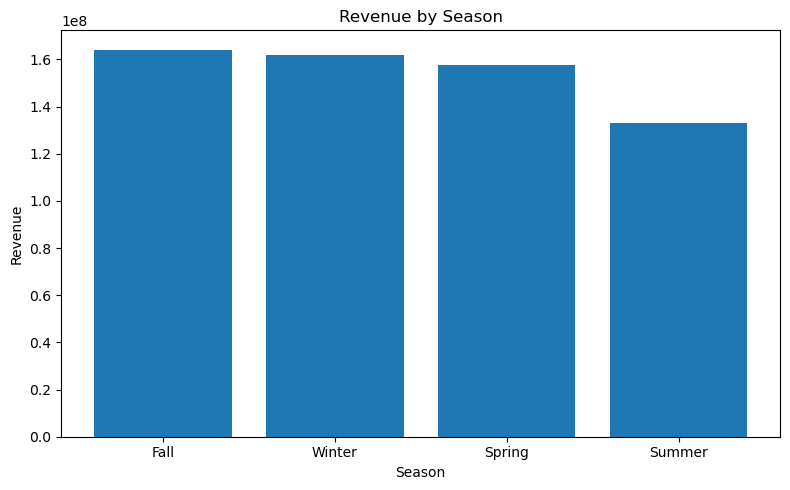

In [36]:

plt.figure(figsize=(8, 5))

plt.bar(
    season_sales["season"],
    season_sales["revenue"]
)

plt.title("Revenue by Season")
plt.xlabel("Season")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

# SKU-level analysis

In [37]:
print("===== TOP SKUS BY REVENUE =====")

sku_sales = df.groupby("sku_id").agg(
    units_sold=("units_sold", "sum"),
    revenue=("revenue", "sum")
).reset_index()

sku_sales = sku_sales.sort_values(
    "revenue", ascending=False
)

print(sku_sales.head(10))

===== TOP SKUS BY REVENUE =====
      sku_id  units_sold      revenue
44   SKU0045       43533  34476923.65
114  SKU0115       27198  24188636.79
95   SKU0096       29000  17663388.41
127  SKU0128       16626  15141664.41
164  SKU0165       19100  14999106.87
170  SKU0171       18528  13494922.77
184  SKU0185       27067  12586076.16
136  SKU0137       23121  12224169.50
112  SKU0113       17441  12139266.87
91   SKU0092       14758  12055307.78


#  plot the Top 10 SKUs by Revenue:

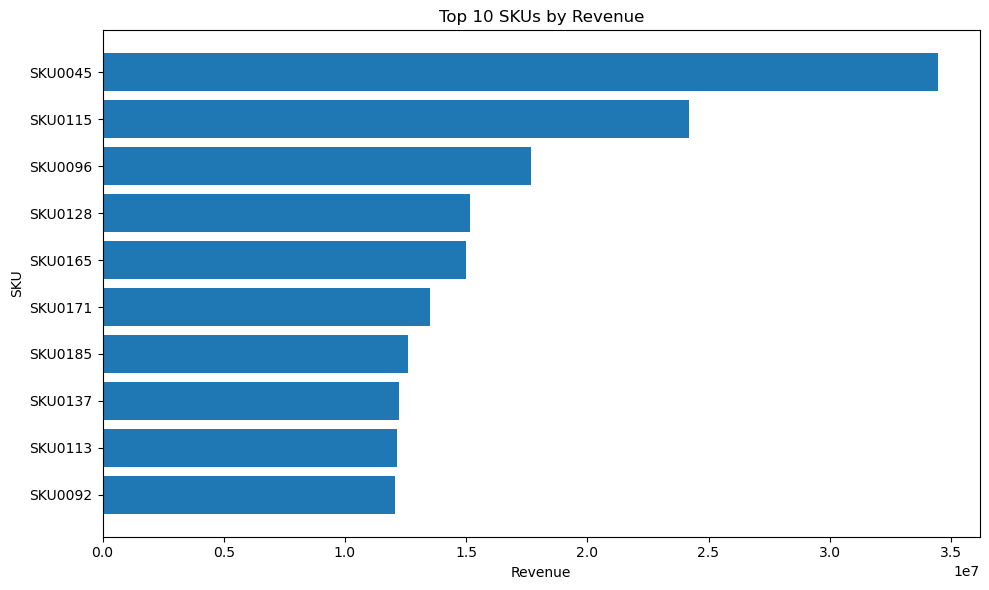

In [38]:
top_10_skus = sku_sales.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_skus["sku_id"],
    top_10_skus["revenue"]
)

plt.title("Top 10 SKUs by Revenue")
plt.xlabel("Revenue")
plt.ylabel("SKU")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

# SKU performance by category

In [39]:
print("===== CATEGORY-SKU PERFORMANCE =====")

category_sku = df.groupby(
    ["category", "sku_id"]
).agg(
    units_sold=("units_sold", "sum"),
    revenue=("revenue", "sum")
).reset_index()

category_sku = category_sku.sort_values(
    "revenue", ascending=False
)

print(category_sku.head(15))

===== CATEGORY-SKU PERFORMANCE =====
      category   sku_id  units_sold      revenue
96   Furniture  SKU0045       43533  34476923.65
123  Furniture  SKU0115       27198  24188636.79
114  Furniture  SKU0096       29000  17663388.41
126  Furniture  SKU0128       16626  15141664.41
150  Furniture  SKU0165       19100  14999106.87
153  Furniture  SKU0171       18528  13494922.77
157  Furniture  SKU0185       27067  12586076.16
132  Furniture  SKU0137       23121  12224169.50
122  Furniture  SKU0113       17441  12139266.87
112  Furniture  SKU0092       14758  12055307.78
136  Furniture  SKU0144       14049  11570404.84
79   Furniture  SKU0004       12620  10710911.80
148  Furniture  SKU0162       15209  10473857.51
92   Furniture  SKU0035       14210  10103478.33
147  Furniture  SKU0160       12334   9868749.25


In [40]:
print("===== TOP 3 SKUS BY CATEGORY =====")

top_skus_by_category = (
    category_sku
    .sort_values(["category", "revenue"], ascending=[True, False])
    .groupby("category")
    .head(3)
)

print(top_skus_by_category)

===== TOP 3 SKUS BY CATEGORY =====
             category   sku_id  units_sold      revenue
25              Decor  SKU0067       25788   3601730.11
68              Decor  SKU0175       25649   2512521.90
17              Decor  SKU0043       12789   2326608.33
96          Furniture  SKU0045       43533  34476923.65
123         Furniture  SKU0115       27198  24188636.79
114         Furniture  SKU0096       29000  17663388.41
190  Small Appliances  SKU0156       23749   7549538.46
173  Small Appliances  SKU0049       23552   4938140.57
177  Small Appliances  SKU0065       19075   4471380.75


# Revenue concentration

This is a useful EDA step for forecasting because we want to know whether a small number of SKUs account for a large share of total revenue.

In [41]:
print("===== REVENUE CONCENTRATION =====")

total_revenue = sku_sales["revenue"].sum()

sku_sales["revenue_share"] = (
    sku_sales["revenue"] / total_revenue * 100
)

sku_sales["cumulative_revenue_share"] = (
    sku_sales["revenue_share"].cumsum()
)

print(sku_sales.head(20)[
    ["sku_id", "revenue", "revenue_share", "cumulative_revenue_share"]
])

===== REVENUE CONCENTRATION =====
      sku_id      revenue  revenue_share  cumulative_revenue_share
44   SKU0045  34476923.65       5.590949                  5.590949
114  SKU0115  24188636.79       3.922549                  9.513498
95   SKU0096  17663388.41       2.864383                 12.377881
127  SKU0128  15141664.41       2.455447                 14.833328
164  SKU0165  14999106.87       2.432330                 17.265658
170  SKU0171  13494922.77       2.188404                 19.454062
184  SKU0185  12586076.16       2.041021                 21.495082
136  SKU0137  12224169.50       1.982332                 23.477414
112  SKU0113  12139266.87       1.968564                 25.445978
91   SKU0092  12055307.78       1.954949                 27.400926
143  SKU0144  11570404.84       1.876314                 29.277240
3    SKU0004  10710911.80       1.736935                 31.014175
161  SKU0162  10473857.51       1.698493                 32.712668
34   SKU0035  10103478.33   

# 80/20 revenue concentration

In [42]:
print("===== 80/20 REVENUE ANALYSIS =====")

# Find the first SKU where cumulative revenue reaches 80%
sku_80 = sku_sales[
    sku_sales["cumulative_revenue_share"] >= 80
].iloc[0]

sku_count_80 = sku_sales[
    sku_sales["cumulative_revenue_share"] <= 80
].shape[0] + 1

total_skus = len(sku_sales)

print("Total SKUs:", total_skus)
print("SKUs needed for 80% of revenue:", sku_count_80)
print("Percentage of SKUs:", 
      round(sku_count_80 / total_skus * 100, 2), "%")
print("Cumulative revenue share:", 
      round(sku_80["cumulative_revenue_share"], 2), "%")

===== 80/20 REVENUE ANALYSIS =====
Total SKUs: 200
SKUs needed for 80% of revenue: 71
Percentage of SKUs: 35.5 %
Cumulative revenue share: 80.08 %


# Sales distribution

In [43]:
print("===== SALES DISTRIBUTION ANALYSIS =====")

print("Units sold skewness:",
      round(df["units_sold"].skew(), 2))

print("Revenue skewness:",
      round(df["revenue"].skew(), 2))

print("\nUnits sold percentiles:")
print(df["units_sold"].quantile([0.50, 0.75, 0.90, 0.95, 0.99]))

print("\nRevenue percentiles:")
print(df["revenue"].quantile([0.50, 0.75, 0.90, 0.95, 0.99]))

===== SALES DISTRIBUTION ANALYSIS =====
Units sold skewness: 2.5
Revenue skewness: 4.84

Units sold percentiles:
0.50     4.0
0.75     8.0
0.90    13.0
0.95    17.0
0.99    28.0
Name: units_sold, dtype: float64

Revenue percentiles:
0.50      614.790
0.75     1870.815
0.90     4510.450
0.95     7107.330
0.99    15071.220
Name: revenue, dtype: float64


# outlier check

In [44]:
print("===== OUTLIER ANALYSIS =====")

Q1_units = df["units_sold"].quantile(0.25)
Q3_units = df["units_sold"].quantile(0.75)
IQR_units = Q3_units - Q1_units

upper_units = Q3_units + 1.5 * IQR_units

Q1_revenue = df["revenue"].quantile(0.25)
Q3_revenue = df["revenue"].quantile(0.75)
IQR_revenue = Q3_revenue - Q1_revenue

upper_revenue = Q3_revenue + 1.5 * IQR_revenue

units_outliers = (df["units_sold"] > upper_units).sum()
revenue_outliers = (df["revenue"] > upper_revenue).sum()

print("Units sold upper bound:", upper_units)
print("Units sold outliers:", units_outliers)

print("Revenue upper bound:", upper_revenue)
print("Revenue outliers:", revenue_outliers)

===== OUTLIER ANALYSIS =====
Units sold upper bound: 18.5
Units sold outliers: 14462
Revenue upper bound: 4494.3375
Revenue outliers: 36764


# sales vs inventory

In [45]:
print("===== INVENTORY & SALES CORRELATION =====")

inventory_corr = df[
    ["on_hand_units", "on_order_units", "reorder_point", "units_sold", "revenue"]
].corr()

print(inventory_corr)

===== INVENTORY & SALES CORRELATION =====
                on_hand_units  on_order_units  reorder_point  units_sold  \
on_hand_units        1.000000       -0.194626       0.623266    0.192195   
on_order_units      -0.194626        1.000000       0.548927    0.328246   
reorder_point        0.623266        0.548927       1.000000    0.445824   
units_sold           0.192195        0.328246       0.445824    1.000000   
revenue              0.195209        0.227199       0.347277    0.673605   

                 revenue  
on_hand_units   0.195209  
on_order_units  0.227199  
reorder_point   0.347277  
units_sold      0.673605  
revenue         1.000000  


## ## Business Insights (for NorthBay Living)

 # 1. **Stockouts are the dominant problem, not dead stock.**  
   198 out of 200 SKUs hit zero inventory at least once. The top offenders (e.g. SKU0127, SKU0192, SKU0049) each had 400–577 stockout days. This directly causes lost sales.

 # 2. **No pure dead stock in the last 90 days.**  
   Every SKU recorded some sales recently. Capital is not currently locked in completely inactive products, but many SKUs still experience frequent stockouts.

# 3. **Revenue is highly concentrated.**  
   A small share of SKUs drives the majority of revenue (from the 80/20 analysis). Forecasting and inventory attention should be prioritised on these top movers first.

# 4. **Promotions lift average revenue.**  
   Days with promotions show higher average revenue than non-promo days. Named events (Memorial Day, Black Friday, etc.) are the strongest drivers.

# 5. **Furniture and Small Appliances drive most revenue but also suffer frequent stockouts.**  
   These categories need tighter reorder discipline and better demand forecasting.